In [6]:
import numpy as np
import os
import torch
import torch.nn as nn

In [5]:
@torch.no_grad()
def check_tanh_encoder_saturation_from_inputs(
    model,
    X,
    device,
    batch_size=1024,
    save_dir=None,
    prefix="tanh_check"
):
    """
    Check Tanh saturation and hidden-representation collapse
    directly from an input matrix X.

    X can be:
        - numpy array, shape [N, in_features]
        - torch tensor, shape [N, in_features]
    """

    model.eval()
    model.to(device)

    if isinstance(X, np.ndarray):
        X = torch.tensor(X, dtype=torch.float32)
    elif torch.is_tensor(X):
        X = X.detach().float().cpu()
    else:
        raise TypeError("X must be a numpy array or torch tensor.")

    all_pre = []
    all_post = []
    all_hid = []

    n = X.size(0)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)

        x = X[start:end].to(device)
        x = x.reshape(x.size(0), -1)

        h1_pre = model.encoder[0](x)
        h1_post = model.encoder[1](h1_pre)
        hid = model.encoder[2](h1_post)

        all_pre.append(h1_pre.detach().cpu())
        all_post.append(h1_post.detach().cpu())
        all_hid.append(hid.detach().cpu())

    pre = torch.cat(all_pre, dim=0)
    post = torch.cat(all_post, dim=0)
    hid = torch.cat(all_hid, dim=0)

    def print_stats(name, tensor):
        print(f"\n{name}")
        print("-" * len(name))
        print("shape:", tuple(tensor.shape))
        print("mean:", tensor.mean().item())
        print("std:", tensor.std().item())
        print("min:", tensor.min().item())
        print("max:", tensor.max().item())
        print("abs mean:", tensor.abs().mean().item())
        print("|x| < 1e-6:", (tensor.abs() < 1e-6).float().mean().item())
        print("|x| < 1e-3:", (tensor.abs() < 1e-3).float().mean().item())

    print_stats("Pre-Tanh activation", pre)
    print_stats("Post-Tanh activation", post)
    print_stats("Hidden representation", hid)

    print("\nTanh saturation")
    print("----------------")
    print("post-Tanh |x| > 0.50:", (post.abs() > 0.50).float().mean().item())
    print("post-Tanh |x| > 0.80:", (post.abs() > 0.80).float().mean().item())
    print("post-Tanh |x| > 0.90:", (post.abs() > 0.90).float().mean().item())
    print("post-Tanh |x| > 0.99:", (post.abs() > 0.99).float().mean().item())

    print("\nHidden collapse")
    print("----------------")
    print("hid std:", hid.std().item())
    print("hid all exactly zero:", bool(torch.all(hid == 0).item()))
    print("hid almost all zero |x| < 1e-6:", (hid.abs() < 1e-6).float().mean().item())

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

        np.save(os.path.join(save_dir, f"{prefix}_pre_tanh.npy"), pre.numpy())
        np.save(os.path.join(save_dir, f"{prefix}_post_tanh.npy"), post.numpy())
        np.save(os.path.join(save_dir, f"{prefix}_hid.npy"), hid.numpy())

        print("\nSaved arrays to:")
        print(os.path.join(save_dir, f"{prefix}_pre_tanh.npy"))
        print(os.path.join(save_dir, f"{prefix}_post_tanh.npy"))
        print(os.path.join(save_dir, f"{prefix}_hid.npy"))

    return {
        "pre_tanh": pre,
        "post_tanh": post,
        "hid": hid,
    }

In [7]:
class TanhFC(nn.Module): 
    def __init__(self):
        super().__init__()
    
    def forward(self, x): 
        pass

    def encode(self, x): 
        pass

    def set_freeze(self): 
        pass

    def set_unfreeze(self):
        for p in self.parameters():
            p.requires_grad = True

class TanhFCEncode(TanhFC):
    def __init__(self, in_features, hid_features, out_features, intermediate_features=None):
        super().__init__()
        if intermediate_features is None:
            intermediate_features = (in_features + hid_features) // 2

        self.encoder = nn.Sequential(
            nn.Linear(in_features, intermediate_features),
            nn.Tanh(),
            nn.Linear(intermediate_features, hid_features)
        )

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        hid = self.encoder(x)
        return hid

In [22]:
X = np.load("./inputs/sihs_0008.npy")
X_flat = X.reshape((1, 15))

model = TanhFCEncode(in_features=15, hid_features=3, out_features=4)
state = torch.load("./weights/0501_RCRC_EQL_EWCp3_1e4_HID3/3/checkpoint_epoch_200.pt", map_location="cpu")
model.load_state_dict(state, strict=False)
model.eval()

TanhFCEncode(
  (encoder): Sequential(
    (0): Linear(in_features=15, out_features=9, bias=True)
    (1): Tanh()
    (2): Linear(in_features=9, out_features=3, bias=True)
  )
)

In [32]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
BASE_DIR = Path("./vectors")
VISUALIZATION_DIR = Path("./visualizations")
OUTPUT_DIR = VISUALIZATION_DIR / "plots_2d_4dims_mean_ci"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

PHONEME_COLUMN = "vowel"

# =========================
# Helper functions
# =========================
def infer_phoneme_column(df: pd.DataFrame) -> str:
    return PHONEME_COLUMN


def get_epoch_from_meta_name(filename: str):
    m = META_PATTERN.match(filename)
    if m:
        return int(m.group(1))
    return None


def get_epoch_from_vec_name(filename: str):
    m = VEC_PATTERN.match(filename)
    if m:
        return int(m.group(1))
    return None


def pair_meta_vec_files(run_dir: Path):
    """
    Pair files like:
      meta_E10_L2.csv
      vec_E10_L2.npy
    by their shared suffix.
    """
    files = [p for p in run_dir.iterdir() if p.is_file()]

    meta_files = {}
    vec_files = {}

    for f in files:
        if f.suffix.lower() == ".csv" and f.name.startswith("meta_"):
            epoch = get_epoch_from_meta_name(f.name)
            if epoch is not None:
                key = f.name[len("meta_"):-4]   # remove "meta_" and ".csv"
                meta_files[key] = (epoch, f)

        elif f.suffix.lower() == ".npy" and f.name.startswith("vec_"):
            epoch = get_epoch_from_vec_name(f.name)
            if epoch is not None:
                key = f.name[len("vec_"):-4]    # remove "vec_" and ".npy"
                vec_files[key] = (epoch, f)

    paired = []
    shared_keys = sorted(set(meta_files.keys()) & set(vec_files.keys()))

    for key in shared_keys:
        meta_epoch, meta_path = meta_files[key]
        vec_epoch, vec_path = vec_files[key]

        if meta_epoch != vec_epoch:
            print(f"[WARN] Epoch mismatch in {run_dir}: {meta_path.name} vs {vec_path.name}")
            continue

        paired.append({
            "epoch": meta_epoch,
            "meta_path": meta_path,
            "vec_path": vec_path
        })

    paired.sort(key=lambda x: x["epoch"])
    return paired


def load_run_data(run_dir: Path, condition_name: str, run_name: str):
    """
    Load all paired meta/vec files for one run.
    Returns one concatenated dataframe with metadata and 4 dimensions.
    """
    pairs = pair_meta_vec_files(run_dir)
    if not pairs:
        print(f"[INFO] No valid meta/vec pairs found in {run_dir}")
        return None

    dfs = []

    for item in pairs:
        epoch = item["epoch"]
        meta_path = item["meta_path"]
        vec_path = item["vec_path"]

        meta_df = pd.read_csv(meta_path)
        vec = np.load(vec_path)

        if vec.ndim == 1:
            vec = vec[:, None]
        elif vec.ndim > 2:
            vec = vec.reshape(vec.shape[0], -1)

        if len(meta_df) != vec.shape[0]:
            raise ValueError(
                f"Row mismatch in {run_dir}\n"
                f"  {meta_path.name}: {len(meta_df)} rows\n"
                f"  {vec_path.name}: {vec.shape[0]} rows"
            )

        # if vec.shape[1] != 4:
        #     raise ValueError(
        #         f"Expected 4 dimensions in {vec_path.name}, but got shape {vec.shape}"
        #     )
        if vec.shape[1] < 4:
            # Pad with NaNs if less than 4 dimensions
            padded_vec = np.full((vec.shape[0], 4), 0)
            padded_vec[:, :vec.shape[1]] = vec
            vec = padded_vec

        this_df = meta_df.copy()
        this_df["epoch"] = epoch
        this_df["condition"] = condition_name
        this_df["run"] = run_name

        this_df["dim_1"] = vec[:, 0]
        this_df["dim_2"] = vec[:, 1]
        this_df["dim_3"] = vec[:, 2]
        this_df["dim_4"] = vec[:, 3]

        dfs.append(this_df)

    df_all = pd.concat(dfs, ignore_index=True)
    return df_all


def summarize_long_df(df_all: pd.DataFrame, ci_level=0.95):
    """
    Convert to long format and compute mean + CI for each:
      epoch × phoneme × dimension
    """
    phoneme_col = infer_phoneme_column(df_all)

    plot_df = df_all.copy()
    plot_df["phoneme_plot"] = plot_df[phoneme_col].astype(str)

    long_df = plot_df.melt(
        id_vars=["epoch", "condition", "run", "phoneme_plot"],
        value_vars=["dim_1", "dim_2", "dim_3", "dim_4"],
        var_name="dimension",
        value_name="value"
    )

    summary = (
        long_df
        .groupby(["epoch", "phoneme_plot", "dimension"], as_index=False)
        .agg(
            mean=("value", "mean"),
            std=("value", "std"),
            n=("value", "size")
        )
    )

    summary["std"] = summary["std"].fillna(0.0)
    summary["sem"] = summary["std"] / np.sqrt(summary["n"])

    if ci_level == 0.95:
        z = 1.96
    elif ci_level == 0.99:
        z = 2.576
    elif ci_level == 0.90:
        z = 1.645
    else:
        z = 1.96

    summary["ci_low"] = summary["mean"] - z * summary["sem"]
    summary["ci_high"] = summary["mean"] + z * summary["sem"]

    return summary


def make_2d_dimension_subplot_mean_ci(df_all: pd.DataFrame, out_html: Path, ci_level=0.95):
    """
    Make 4 subplots:
      one per dimension
    Plot:
      x = epoch
      y = mean dimension value
      color = phoneme
      shaded region = CI
    """
    summary = summarize_long_df(df_all, ci_level=ci_level)

    dims = ["dim_1", "dim_2", "dim_3", "dim_4"]
    phonemes = sorted(summary["phoneme_plot"].unique())

    fig = make_subplots(
        rows=2,
        cols=2,
        subplot_titles=dims,
        shared_xaxes=True
    )

    dim_to_pos = {
        "dim_1": (1, 1),
        "dim_2": (1, 2),
        "dim_3": (2, 1),
        "dim_4": (2, 2),
    }

    line_palette = [
        "rgb(99,110,250)",
        "rgb(239,85,59)",
        "rgb(0,204,150)",
        "rgb(171,99,250)",
        "rgb(255,161,90)",
        "rgb(25,211,243)",
        "rgb(255,102,146)",
        "rgb(182,232,128)",
        "rgb(255,151,255)",
        "rgb(254,203,82)"
    ]
    fill_palette = [
        "rgba(99,110,250,0.20)",
        "rgba(239,85,59,0.20)",
        "rgba(0,204,150,0.20)",
        "rgba(171,99,250,0.20)",
        "rgba(255,161,90,0.20)",
        "rgba(25,211,243,0.20)",
        "rgba(255,102,146,0.20)",
        "rgba(182,232,128,0.20)",
        "rgba(255,151,255,0.20)",
        "rgba(254,203,82,0.20)"
    ]

    phoneme_to_line = {
        ph: line_palette[i % len(line_palette)]
        for i, ph in enumerate(phonemes)
    }
    phoneme_to_fill = {
        ph: fill_palette[i % len(fill_palette)]
        for i, ph in enumerate(phonemes)
    }

    for dim in dims:
        r, c = dim_to_pos[dim]
        dim_df = summary[summary["dimension"] == dim].copy()

        for ph in phonemes:
            sub = dim_df[dim_df["phoneme_plot"] == ph].sort_values("epoch")
            if sub.empty:
                continue

            line_color = phoneme_to_line[ph]
            fill_color = phoneme_to_fill[ph]

            # Upper CI boundary
            fig.add_trace(
                go.Scatter(
                    x=sub["epoch"],
                    y=sub["ci_high"],
                    mode="lines",
                    line=dict(width=0),
                    hoverinfo="skip",
                    showlegend=False,
                    legendgroup=ph
                ),
                row=r, col=c
            )

            # Lower CI boundary + fill
            fig.add_trace(
                go.Scatter(
                    x=sub["epoch"],
                    y=sub["ci_low"],
                    mode="lines",
                    line=dict(width=0),
                    fill="tonexty",
                    fillcolor=fill_color,
                    hoverinfo="skip",
                    showlegend=False,
                    legendgroup=ph
                ),
                row=r, col=c
            )

            # Mean line
            fig.add_trace(
                go.Scatter(
                    x=sub["epoch"],
                    y=sub["mean"],
                    mode="lines",
                    line=dict(width=2, color=line_color),
                    name=ph,
                    legendgroup=ph,
                    showlegend=(dim == "dim_1"),
                    customdata=np.stack(
                        [sub["n"], sub["ci_low"], sub["ci_high"]],
                        axis=-1
                    ),
                    hovertemplate=(
                        "Phoneme=%{fullData.name}<br>"
                        "Epoch=%{x}<br>"
                        "Mean=%{y:.4f}<br>"
                        "n=%{customdata[0]}<br>"
                        "CI=[%{customdata[1]:.4f}, %{customdata[2]:.4f}]"
                        "<extra></extra>"
                    )
                ),
                row=r, col=c
            )

    title = f"{df_all['condition'].iloc[0]} | run {df_all['run'].iloc[0]}"

    fig.update_layout(
        title=title,
        height=900,
        width=1200,
        template="plotly_white",
        legend_title_text="Phoneme"
    )

    fig.update_xaxes(title_text="Epoch")
    fig.update_yaxes(title_text="Mean dimension value")

    fig.write_html(str(out_html))
    print(f"[SAVED] {out_html}")


# =========================
# Main
# =========================
def main():
    INCLUDE_PREFIX = "0501"
    if not BASE_DIR.exists():
        raise FileNotFoundError(f"Base directory not found: {BASE_DIR}")

    condition_dirs = [
        p for p in BASE_DIR.iterdir()
        if p.is_dir() and not p.name.endswith(".csv")
    ]

    condition_dirs = [
        p for p in condition_dirs
        if p.name.startswith(f"{INCLUDE_PREFIX}")
    ]

    for condition_dir in sorted(condition_dirs):
        condition_name = condition_dir.name

        run_dirs = [
            p for p in condition_dir.iterdir()
            if p.is_dir() and not p.name.endswith(".csv")
        ]

        for run_dir in sorted(run_dirs, key=lambda p: p.name):
            run_name = run_dir.name
            print(f"[PROCESSING] condition={condition_name}, run={run_name}")

            try:
                df_all = load_run_data(run_dir, condition_name, run_name)
                if df_all is None:
                    continue

                out_html = OUTPUT_DIR / f"{condition_name}__run_{run_name}__4dim_mean_ci.html"
                make_2d_dimension_subplot_mean_ci(df_all, out_html, ci_level=0.95)

            except Exception as e:
                print(f"[ERROR] Failed on {run_dir}: {e}")


if __name__ == "__main__":
    main()

(80000, 3)

In [28]:
X_tensor = torch.tensor(X_flat, dtype=torch.float32).to("cpu")
with torch.no_grad():
    hid = model(X_tensor)

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_hidrep_histograms(
    meta_path,
    vec_path,
    color_col="vowel",
    vowel_select=None,
    bins=40,
    alpha=0.45,
    density=True,
    save_dir=None,
    prefix="hidrep_hist",
):
    """
    Plot one histogram for each hidden dimension, grouped by vowel.

    Parameters
    ----------
    vowel_select : list[str] or None
        If provided, only plot these vowels, e.g. ["i", "ih", "e"].
    """

    meta = pd.read_csv(meta_path)
    vec = np.load(vec_path)

    if len(meta) != vec.shape[0]:
        raise ValueError(
            f"Row mismatch: meta has {len(meta)} rows, "
            f"but vec has {vec.shape[0]} rows."
        )

    if color_col not in meta.columns:
        raise ValueError(f"{color_col} is not in metadata columns.")

    # Filter selected vowels
    if vowel_select is not None:
        vowel_select = list(vowel_select)
        mask = meta[color_col].isin(vowel_select).to_numpy()

        meta = meta.loc[mask].reset_index(drop=True)
        vec = vec[mask]

        if len(meta) == 0:
            raise ValueError(
                f"No rows left after filtering {color_col} by {vowel_select}."
            )

    df = meta.copy()

    for d in range(vec.shape[1]):
        df[f"dim_{d}"] = vec[:, d]

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for d in range(vec.shape[1]):
        dim_col = f"dim_{d}"

        plt.figure(figsize=(7, 5))

        for label, g in df.groupby(color_col):
            plt.hist(
                g[dim_col],
                bins=bins,
                alpha=alpha,
                density=density,
                label=str(label),
            )

        plt.xlabel(f"Hidden dimension {d}")
        plt.ylabel("Density" if density else "Count")
        plt.title(f"Distribution of hidden dimension {d}")
        plt.legend(title=color_col)
        plt.tight_layout()

        if save_dir is not None:
            out_path = os.path.join(save_dir, f"{prefix}_dim{d}.png")
            plt.savefig(out_path, dpi=300, bbox_inches="tight")
            print(f"Saved: {out_path}")

        plt.show()

    return df

Saved: hidrep_histograms/E200_L2_i_ih_iS_ihL_dim0.png


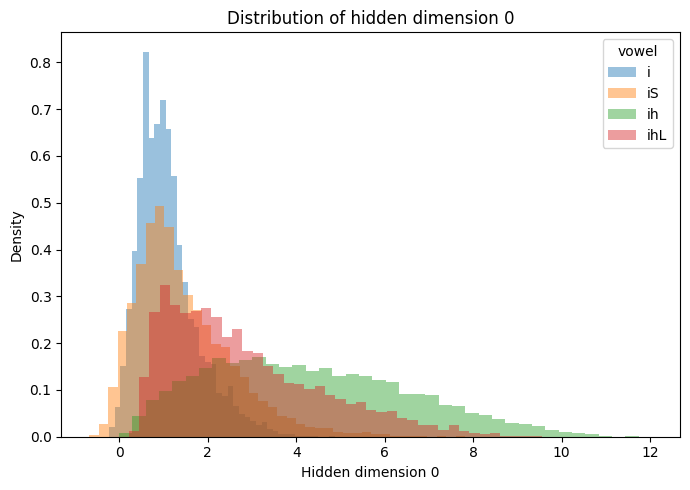

Saved: hidrep_histograms/E200_L2_i_ih_iS_ihL_dim1.png


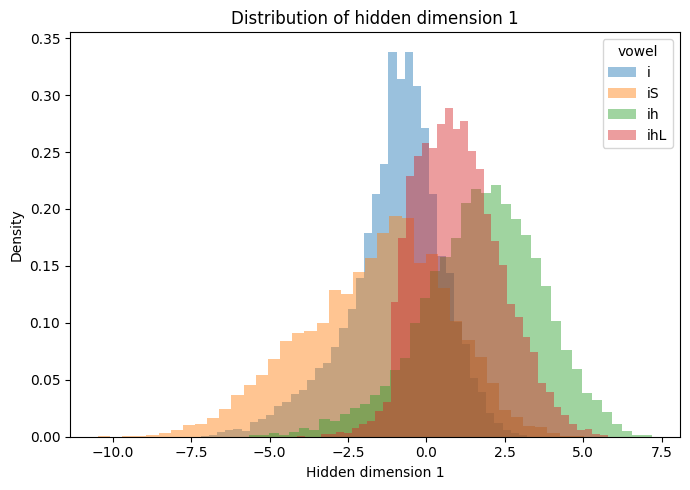

Saved: hidrep_histograms/E200_L2_i_ih_iS_ihL_dim2.png


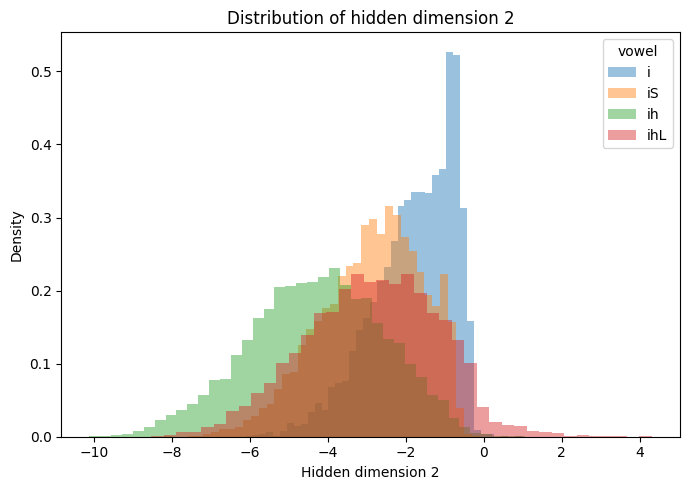

In [41]:
df = plot_hidrep_histograms(
    meta_path="./inputs/meta_E200_L2.csv",
    vec_path="./inputs/vec_E200_L2.npy",
    color_col="vowel",
    vowel_select=["i", "ih", "iS", "ihL"],
    bins=40,
    density=True,
    save_dir="hidrep_histograms",
    prefix="E200_L2_i_ih_iS_ihL"
)

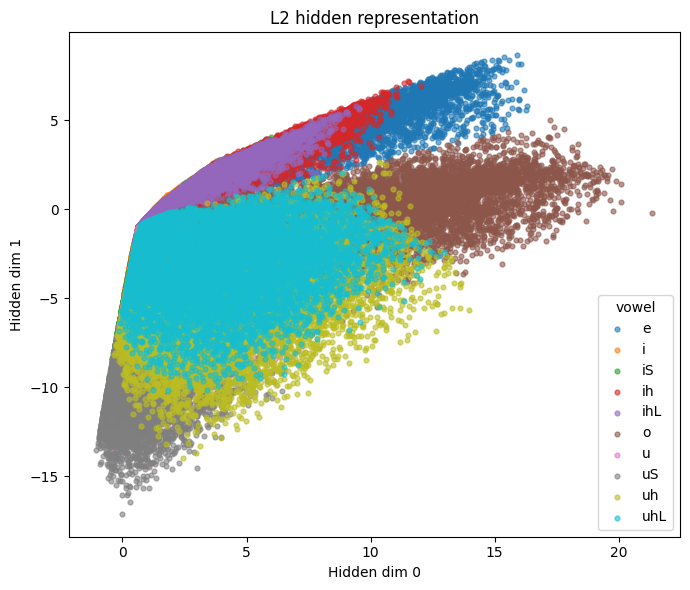

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

meta = pd.read_csv("./inputs/meta_E200_L2.csv")
vec = np.load("./inputs/vec_E200_L2.npy")

color_col = "vowel"
x_dim=0
y_dim=1
title="L2 hidden representation"
alpha=0.6
s=12

df = meta.copy()
for d in range(vec.shape[1]):
    df[f"dim_{d}"] = vec[:, d]

sample_n = None

if sample_n is not None and sample_n < len(df):
    df = df.sample(sample_n, random_state=42)

groups = df.groupby(color_col)

plt.figure(figsize=(7, 6))

for label, g in groups:
    plt.scatter(
        g[f"dim_{x_dim}"],
        g[f"dim_{y_dim}"],
        label=str(label),
        alpha=alpha,
        s=s,
    )

plt.xlabel(f"Hidden dim {x_dim}")
plt.ylabel(f"Hidden dim {y_dim}")

if title is None:
    title = f"Hidden representation scatter: dim {x_dim} vs dim {y_dim}"
plt.title(title)

plt.legend(title=color_col)
plt.tight_layout()

In [23]:
result = check_tanh_encoder_saturation_from_inputs(
    model=model,
    X=X_flat,
    device="cpu",
    batch_size=1024,
    save_dir="./debug_tanh",
    prefix="E300_L2"
)


Pre-Tanh activation
-------------------
shape: (1, 9)
mean: -0.11245327442884445
std: 0.27612367272377014
min: -0.5345582365989685
max: 0.4172590374946594
abs mean: 0.22069765627384186
|x| < 1e-6: 0.0
|x| < 1e-3: 0.0

Post-Tanh activation
--------------------
shape: (1, 9)
mean: -0.1066456288099289
std: 0.2581118643283844
min: -0.4888577163219452
max: 0.39461880922317505
abs mean: 0.20983368158340454
|x| < 1e-6: 0.0
|x| < 1e-3: 0.0

Hidden representation
---------------------
shape: (1, 3)
mean: 0.06211596727371216
std: 0.2694340646266937
min: -0.17093855142593384
max: 0.3571338653564453
abs mean: 0.17607499659061432
|x| < 1e-6: 0.0
|x| < 1e-3: 0.3333333432674408

Tanh saturation
----------------
post-Tanh |x| > 0.50: 0.0
post-Tanh |x| > 0.80: 0.0
post-Tanh |x| > 0.90: 0.0
post-Tanh |x| > 0.99: 0.0

Hidden collapse
----------------
hid std: 0.2694340646266937
hid all exactly zero: False
hid almost all zero |x| < 1e-6: 0.0

Saved arrays to:
./debug_tanh/E300_L2_pre_tanh.npy
./debug_tan